# Print Results

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import deepinv as dinv
from deepinv.physics import Denoising, GaussianNoise, PoissonNoise
from deepinv.utils.demo import load_url_image, get_image_url
from deepinv.utils.plotting import plot

from opt_functions.plot_results import *
        
import ISM.simulation.PSF_sim as ism
import ISM.analysis.Graph_lib as gr


Using device: cuda


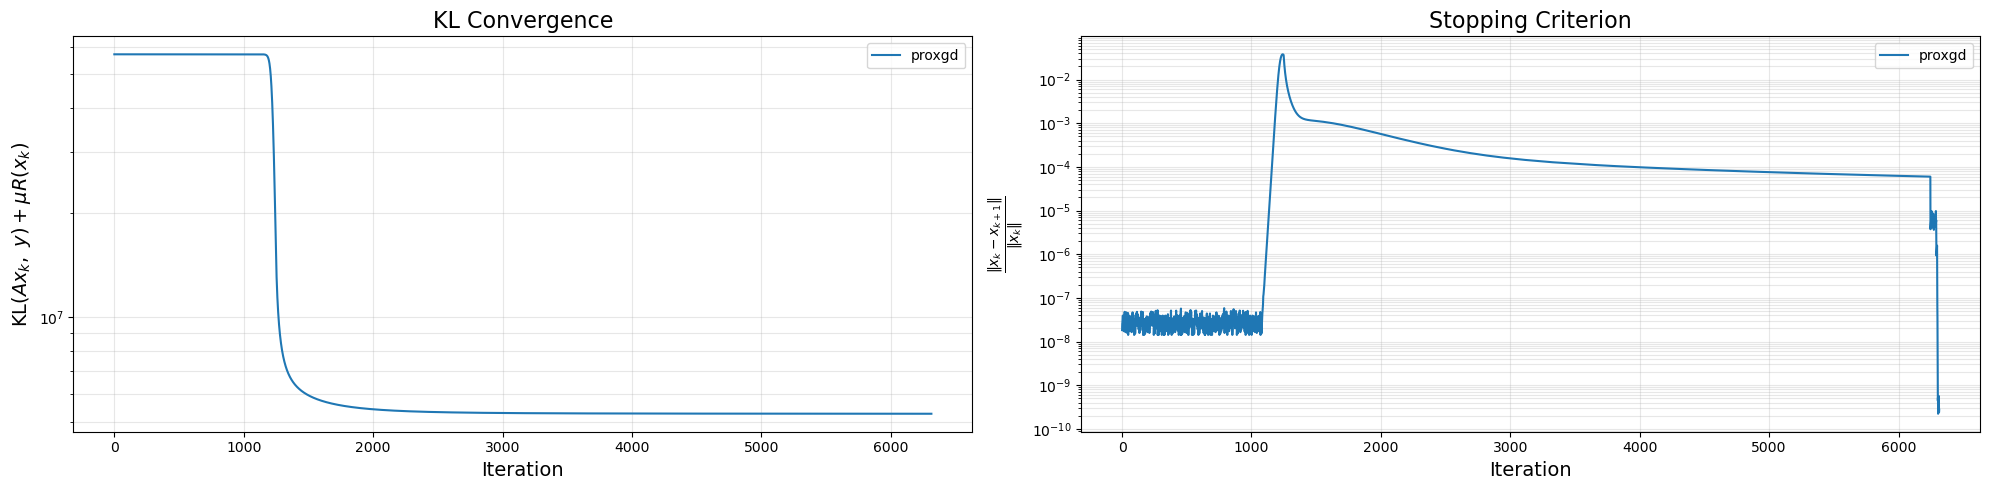

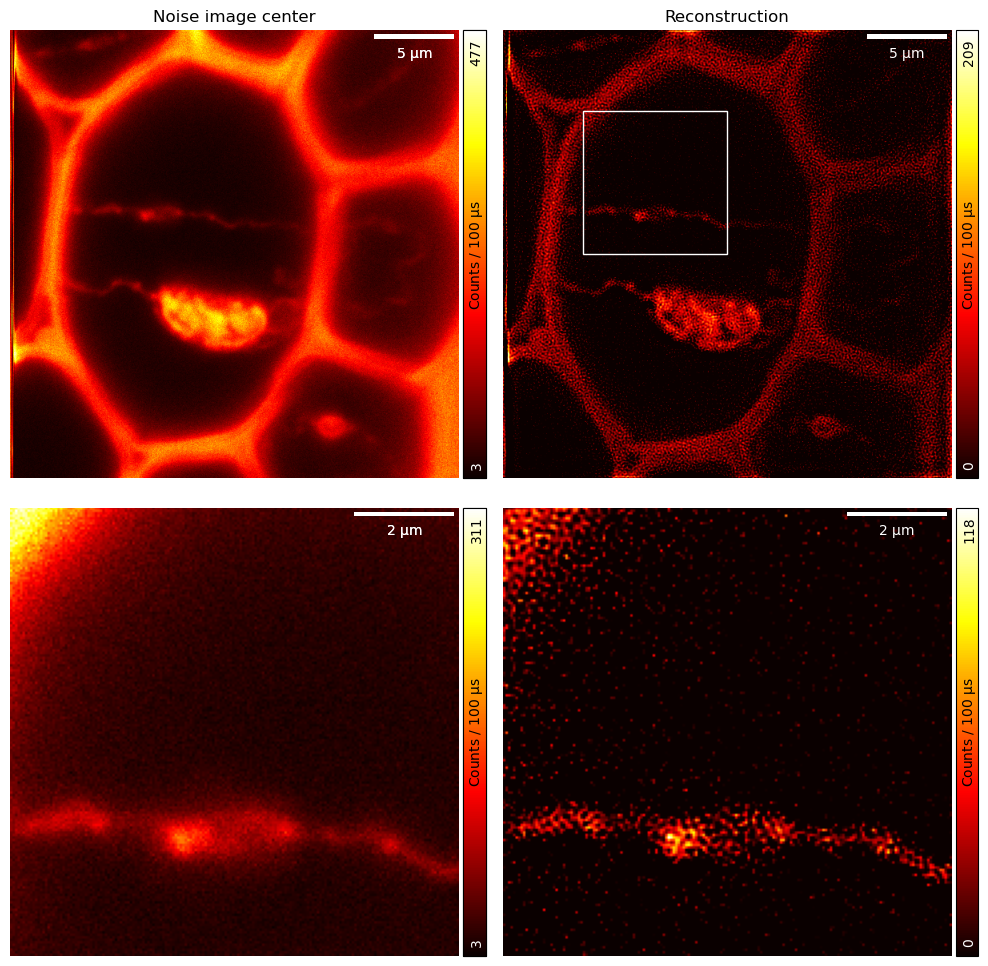

In [19]:
lam_to_load = 0.1
algo_to_load = "prox"                # pgd or prox or md
name_to_load = "05_convallaria"     # tubulin for sim
sect_to_load = "3D"                 # 3D or 2D
real_to_load = "real"               # real o sim

path = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_{algo_to_load}_{name_to_load}_lam{lam_to_load}.pth"

checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']


plot_results(results, dataset, hparams['IS_REAL'], hparams['IS_3D'], hparams['pxsize'], x0_sec = 100, y0_sec = 100)


# WHITE PRINCIPLE

--- Risultati per WP ---
Mu ottimale (min WP): 0.000000e+00 con WP = 5.668787e+03


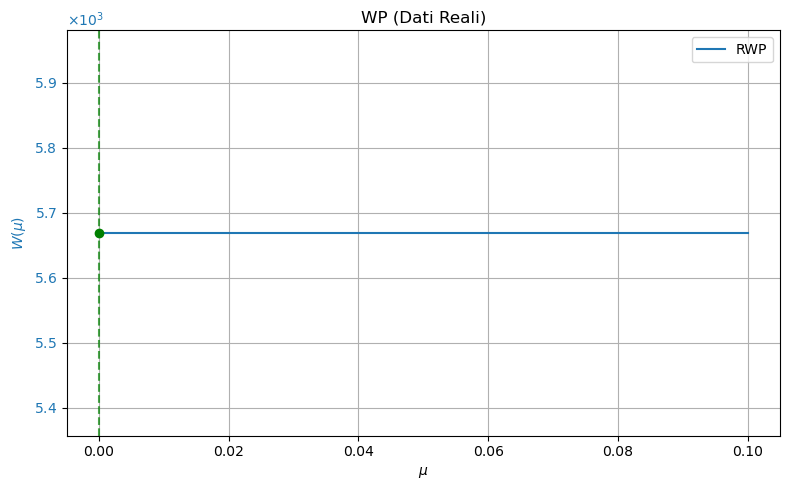

KeyError: 'funct'

In [2]:
# path = "Results/WP/wp_3D_pgd_masked_06_convallaria.pth"
mask_type = 'masked'
algo_to_load = "pgd"                # pgd or prox or md
name_to_load = "05_convallaria"     # tubulin for sim
sect_to_load = "3D"                 # 3D or 2D

path = f"Results/WP/wp_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"


checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']

plot_wp_results(hparams['mu_grid'], results, dataset, hparams['pxsize'], is_real= hparams['IS_REAL'], is_3d = hparams['IS_3D'], title="WP", layout="stacked")